<a href="https://colab.research.google.com/github/kidujm/data_class/blob/main/20260310.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:

import pandas as pd
import numpy as np

# Install Korean font
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# Configure Matplotlib to use NanumGothic
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # To prevent breaking minus sign

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (6,881 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117540 files and direc

In [ ]:
book = pd.read_csv('도서데이터_정제완료_대출범주_추가 (1).csv')

In [ ]:
book

## 인코딩
- 머신러닝알고리즘은 수학적 수식과 행렬 연산을 기반으로 작동하므로, 텍스트나 문자열 형태의 데이터를 직접 처리할 수 없습니다. 인코딩은 모델이 **연산을 수행할 수 있도록 범주형 데이터를 수치형 데이터로 변환하는 필수 전처리 과정**
- 출판사 : target -> 대출건수의 평균으로 재인코딩
- **타겟 인코딩은 범주형 변수의 각 범주를 해당범주에 속하는 데이터의 종속 변수 평균값으로 대체하는 데이터 변환 기법 **
- 출판연도 : label
- 알라딘_분류 : onr-hot
## 스케일(min_max)
- 페이지,가격

범주형describe 출력물 주고 분석해달라고 하기
데이터프레임 원본 있으니까 인코딩 된거 덮어씌워
(가격을 스케일 했다면 원본가격 제거 해야함)

In [ ]:
book = book[['출판사', '출판연도', '단행/시리즈', '페이지', '가격', '알라딘_분류','성비_여성', '대출(범주)']]

In [ ]:
book['출판사'].value_counts()

,count
출판사,
문학동네,213
민음사,159
책읽는곰,156
창비,141
비룡소,117
...,...
청어람,1
국수,1
딥앤와이드,1


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. '출판사' : Target Encoding (레이블: '대출(범주)')
book['출판사'] = book.groupby('출판사')['대출(범주)'].transform('mean')

# 2. '출판연도' : Label Encoding
le = LabelEncoder()
book['출판연도'] = le.fit_transform(book['출판연도'])

# 3. '알라딘_분류' : One-Hot Encoding
book = pd.get_dummies(book, columns=['알라딘_분류'])

In [ ]:
features = book.drop('대출(범주)', axis=1)
target = book['대출(범주)']

In [ ]:
features.loc[features['단행/시리즈'] == '단행본', '단행/시리즈'] = True

In [ ]:
features.loc[features['단행/시리즈'] == '시리즈', '단행/시리즈'] = False

In [ ]:
features

,출판사,출판연도,단행/시리즈,페이지,가격,성비_여성,알라딘_분류_0~3세,알라딘_분류_4~7세,알라딘_분류_TV/만화/영화,알라딘_분류_e비즈니스/창업,...,알라딘_분류_추리/미스터리소설,알라딘_분류_태교,알라딘_분류_판타지/환상문학,알라딘_분류_프랑스소설,알라딘_분류_한국소설,알라딘_분류_한국에세이,알라딘_분류_행복론,알라딘_분류_협상/설득/화술,알라딘_분류_호러.공포소설,알라딘_분류_희곡
0,0.716312,21,True,216.0,13500,0.7,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,0.694836,28,True,336.0,12600,0.8,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,0.694836,28,True,332.0,15120,0.7,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,1.600000,20,True,308.0,11700,0.8,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,1.600000,26,True,368.0,13500,0.9,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3681,0.200000,31,True,40.0,13500,0.9,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3682,0.436364,20,True,40.0,9000,0.9,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3683,0.000000,29,False,192.0,10800,0.9,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3684,0.323529,32,True,32.0,13500,0.8,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# 페이지	가격 스케일
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
features[['페이지', '가격', '성비_여성']] = scaler.fit_transform(features[['페이지', '가격', '성비_여성']])

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score , cross_validate

import numpy as np

dt_clf = DecisionTreeClassifier(random_state=1)
rf_clf = RandomForestClassifier(random_state=1)
gb_clf = GradientBoostingClassifier(random_state=1)


models = {
    '결정트리': dt_clf,
    '랜덤포레스트': rf_clf,
    '그레이디언트부스팅': gb_clf,
}

for name, model in models.items():
  scores = cross_val_score(model , features , target , scoring='accuracy',cv=5)
  print(f'모델명:{name}')
  print('교차 검증별 정확도:',np.round(scores, 4))
  print('평균 검증 정확도:', np.round(np.mean(scores), 4))
  print('-'*40)

모델명:결정트리
교차 검증별 정확도: [0.5054 0.5156 0.5672 0.5414 0.5387]
평균 검증 정확도: 0.5336
----------------------------------------
모델명:랜덤포레스트
교차 검증별 정확도: [0.5528 0.5739 0.5848 0.5916 0.5672]
평균 검증 정확도: 0.5741
----------------------------------------
모델명:그레이디언트부스팅
교차 검증별 정확도: [0.5908 0.6011 0.5834 0.6024 0.5699]
평균 검증 정확도: 0.5895
----------------------------------------


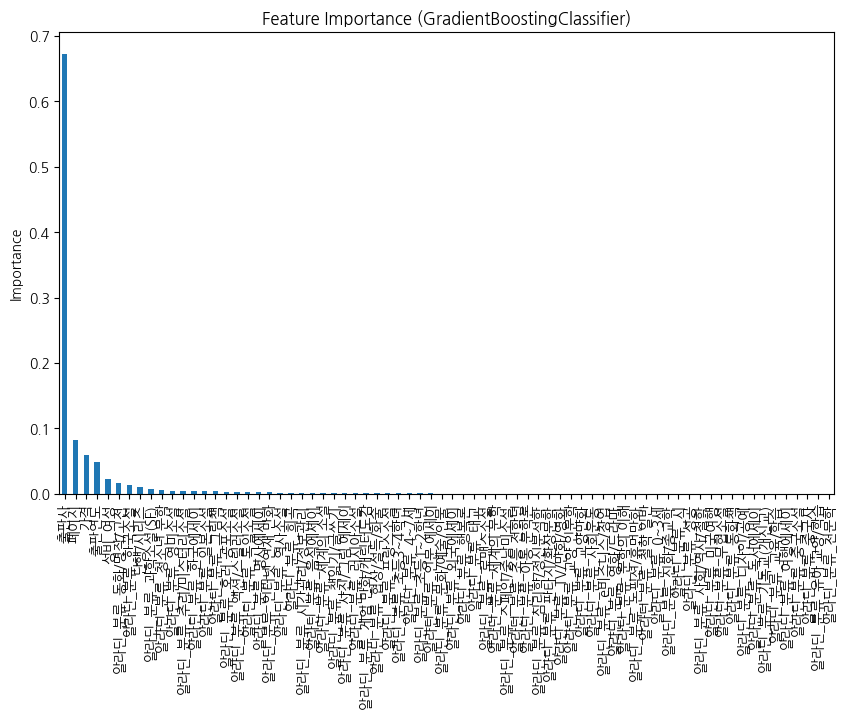

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

gb_clf.fit(features, target)

importances = gb_clf.feature_importances_

feat_imp = pd.Series(importances, index=features.columns).sort_values(ascending=False)

# 시각화
plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar')
plt.title('Feature Importance (GradientBoostingClassifier)')
plt.ylabel('Importance')
plt.show()

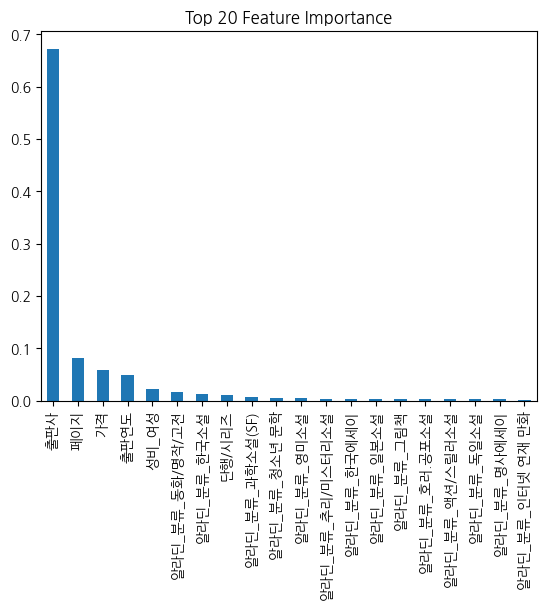

In [ ]:
feat_imp.head(20).plot(kind='bar')
plt.title('Top 20 Feature Importance')
plt.show()
# 대출건수에 영향을 주는 것은 출판사,페이지,가격,출판연도,성비가 분류보다 영향을 많이 미치더라
# 자사경쟁사가 출판사면 출판사는 빼고 봐야함 < 출판사는 우리가 조절할 수 없으니

# 회귀
### 회귀 분석의 기본원리
- 부모와 자식간 키의 상관관계
    1. 부모의 키가 모두 클때 > 자식의 키는 크지만 부모를 능가할 정도는 아님
    2. 부모의 키가 모두 작을때 > 자식의 키는 작지만 부모보다는 큼
    3. 부모의 키가 아주 커도 자식이 더 커져서 세대를 이어가며 무한정 커지진 않음
    4. 작은 경우도 마찬가지.
    즉, 사람의 키는 평균키로 회귀 하려는 경향을 가진다(자연적인 법칙)

**머신러닝의 회귀(Regression) 예측**이란 간단히 말해서:

- **과거 데이터를 기반으로 숫자 값을 예측하는 방법**

예를 들어:

- 집의 크기, 위치, 방 개수 같은 데이터를 활용해서 → 집값(숫자)을 예측하거나,
- 공부한 시간, 수업 참여율을 가지고 → 시험 점수(숫자)를 예측하는 겁니다.

---

### 회귀 예측이 작동하는 방식:

**① 데이터 수집**  

집 크기 | 방 개수 | 집값  
:---: | :---: | :---:  
80㎡ | 3개 | 3억 원  
100㎡ | 4개 | 4억 원  
120㎡ | 5개 | 5억 원  

**② 머신러닝 모델이 데이터로부터 규칙(패턴)을 학습**  
- "크기가 클수록, 방이 많을수록 집값이 오른다."

**③ 새로운 데이터가 들어오면 학습한 규칙을 이용해 값을 예측**  
예: "90㎡, 방 3개"의 집 → "약 3.5억 원"이라고 예측

---


### 독립변수와 종속변수
    * 독립: 아파트 방의 갯수, 방크기, 주변학군등 여러개 (피처)
    * 종속: 아파트 가격 (결정값)
    - > 머신러닝에서 회귀 예측의 핵심
    

- 회귀계수
    * 선형 : 실제값과 예측값의 차이를 최소화하는 선을 최적화

### 한 줄 정리:
* 주어진 피처와 결정값 데이터 학습을 통해 최적의 회귀 계수를 찾는것.
* 즉, 회귀 예측은 **이전 데이터를 기반으로 숫자 값을 예측하는 머신러닝 방법**

### 일반선형 회귀 (Linear Regression): 입력/출력 사이 선형관계를 계산
- **장점**: 단순하고 해석이 쉬움, 계산이 빠름, 작은 데이터셋에서도 잘 작동.
- **단점**: 이상치(outlier)에 민감, 다중공선성 문제 발생 가능.

---

### 릿지 회귀 (Ridge Regression)
- **장점**: L2 정규화를 통해 다중공선성을 완화, 과적합 방지.
- **단점**: 모델의 희소성(sparsity)을 제공하지 않음, 변수 선택 불가능.
- 불필요한, 중요하지 않은 특성을 제거. 모델 학습에 노이즈 영향을 줄임.
- 가중치를 너무 크게 만들지 말자. -> 덜 복잡해짐

---

### 라쏘 회귀 (Lasso Regression)
- **장점**: L1 정규화를 통해 가중치를 0으로 만들어 변수 선택 가능, 희소성 확보.
- **단점**: 변수 선택이 과도할 경우 중요한 변수를 누락할 위험.
- 중요하지 않은 변수는 아예 삭제(가중치0).

---

### 엘라스틱넷 회귀 (Elastic Net Regression)
- **장점**: L1과 L2 정규화를 조합하여 릿지와 라쏘의 장점을 모두 활용, 다중공선성과 변수 선택 문제 동시 해결.
- **단점**: 두 개의 하이퍼파라미터(alpha, l1_ratio) 튜닝 필요, 설정 복잡성 증가.

---
- 여기서부터 사용
### 로지스틱 회귀 (Logistic Regression): 실제로 분류에서 굉장히 잘 동작함. (이진분류에서 확률출력 제공)
- **장점**: 분류 문제에서 확률적 출력 제공, 해석이 용이, 계산 효율적.
- **단점**: 선형 관계가 아닌 경우 성능 저하, 복잡한 비선형 경계를 처리하기 어려움.

### 결정 트리(Decision Tree): 데이터를 분기(나눈다)해서 예측하는 방식.
- **장점**: 해석도 쉽고, 비선형 관계도 학습 가능.
- **단점**: 과적합에 약함.

### 랜덤 포레스트(Random Forest): 더 복잡한 데이터를 잘 다룰 수 있는 고급 방법.
- **장점**: 과적합 감소(결정트리 단점 보완), 각 변수 중요도 확인가능, 비선형 처리가능
- **단점**: 계산비용 증가, 모델자체 해석은 어려울 수 있다.

### 그래디언트 부스팅 (Gradient Boosting): 앙상블 기법 (복수 알고리즘 결합). 순차적으로 오차를 줄이는 방향으로 모델을 개선함.
- 기본모델: GBM
- 향상모델: XGBoost(속도향상), LightGBM(대량의데이터처리), CatBoost(범주형에 강함)
- 과적합 위험이 굉장히 적으며(튜닝시) 데이터 편향(왜곡)에도 강하다.

### 서포트벡터머신 (SVM): 이득이 최대가 되는 경계를 찾아가기.
- 고차원에 강함, 비선형 분류 가능
- 대규모 데이터에서 느림, 파라미터 설정에 매우 민감

- 느리다는건 단점
- xgbo부스팅은 범주형에 강함
- 마케팅에서는 머신러닝 수준으로 충분함

## 평가 수치
-  정확도는 분류 문제에서 사용되는 지표로, 예측값이 실제값과 정확히 일치하는 비율을 측정합니다. 회귀 문제에서는 예측값이 연속적인 값이므로, 정확도가 의미가 없습니다.

### R²(모델의 설명력)
- 모델이 전체 변동성 중에서 얼마나 설명할 수 있는지.
  R² 값이 0.7 이상이면 모델이 데이터를 잘 설명한다고 볼 수 있습니다.
  이 값만으로는 모델의 성능을 완전히 평가할 수 없으므로 다른 지표들과 함께 분석해야 함

- 데이터에 대한 모델의 이해도.
- > 만원이라고 예측했는데 이유를 70퍼센트 설명할 수 있음

### MAE
- 예측값과 실제값 사이의 평균 절대 오차.
  MAE 값이 작을수록 모델의 예측이 실제 값에 가까움.
  오차의 크기를 직관적으로 이해
- 오차 평균이기 때문에 직관적이나,오차크기의 분포(방향)를 놓침
- 이상치 영향 파악이 안됨 (예, 굉장히 큰 오차가 하나 있어도 파악이 어려움) -> 설명력이 부족하다.
- 따라서, MAE와 R2를 같이 확입합니다.

# MSE
오차의 제곱 평균을 측정.
큰 오차에 대해 더 많은 페널티.
- 제곱하면 10 >100
  50 >2500

MSE 값이 작을수록 좋습니다.
큰 오차가 중요한 문제에서는 MSE를 중요하게 고려.
- 단점: 직관적인 해석이 어려움.

# RMSE
MSE의 제곱근을 취하여 실제 값의 단위와 일치시킵니다.
RMSE는 MSE와 유사하지만, 해석이 더 쉬운 지표입니다.
MAE와 함께 사용하여 모델의 예측 성능을 종합적으로 평가합니다.

In [6]:
sports = pd.read_csv('train_sports.csv')

In [ ]:
sports

,장소,관중수,월,종목,지역,요일,경기전_검색률,경기전_선호도,경기후_검색률,경기후_선호도
0,원주종합체육관,1203,2023년 1월,농구,강원도,월,10.931216,40,61.997326,226
1,원주종합체육관,1316,2024년 1월,NaN,강원도,목,17.837188,80,55.333882,248
2,원주종합체육관,1719,2024년 1월,농구,강원도,화,27.186975,120,73.443669,324
3,원주종합체육관,2084,2023년 1월,농구,강원도,월,61.827504,160,151.865209,393
4,원주종합체육관,2287,2023년 1월,농구,강원도,화,62.922925,200,135.688774,431
...,...,...,...,...,...,...,...,...,...,...
4997,천안유관순체육관,1554,2024년 12월,배구,충청남도,수,14.644260,264,20.927297,377
4998,천안유관순체육관,1678,2024년 12월,배구,충청남도,목,18.216786,308,24.094151,407
4999,천안유관순체육관,2626,2022년 12월,배구,충청남도,일,46.478976,352,84.179673,637
5000,천안유관순체육관,3048,2024년 12월,배구,충청남도,일,27.818478,396,51.981854,739


In [ ]:
# 관중수 예측 -> 매출 / 주차 /음식
#년 정보/월정보 넣어보고 년정보는 뺀다
# 장소가 있으면 지역은 빼야한다 왜냐하면 너무 연관성이 높으니까
#히트맵 그려봐서 상관계수 0.8 넘으면 삭제해야함
# 학습할 때는 경기후는 필요없음

# feature 와 target 선택
- 장소 , 연 , 월(성능이 낮아지더라도 넣어야함 ) , 종목, 요일 ,경기전 검색률
- target: 관중수

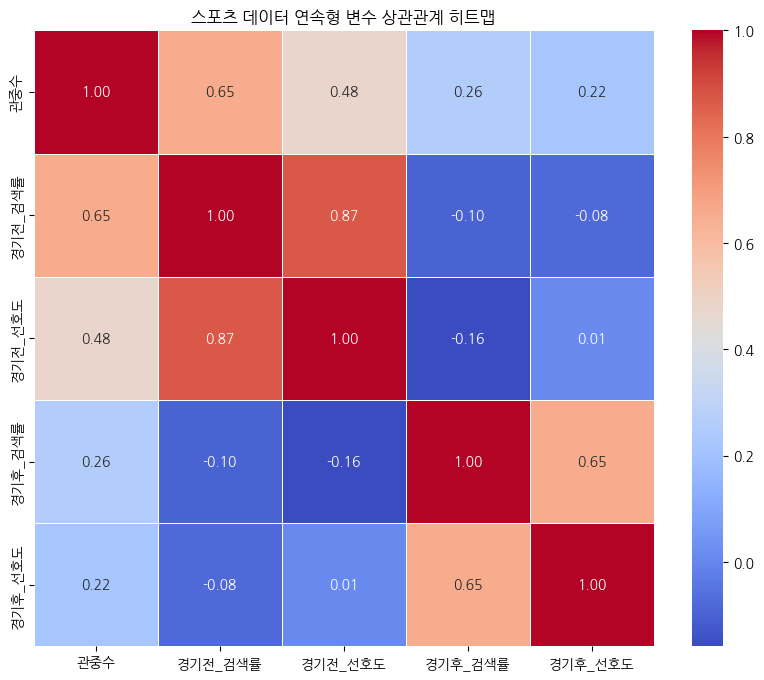

In [7]:
# sports 연속형 변수 히트맵
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
sports_numeric = sports.select_dtypes(include=['number'])

# Calculate the correlation matrix
corr_matrix = sports_numeric.corr()

# Create the heatmap
plt.figure(figsize=(10, 8)) # Adjust figure size as needed
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('스포츠 데이터 연속형 변수 상관관계 히트맵')
plt.show()

In [8]:
sports = sports[['장소', '월', '종목', '요일', '경기전_검색률','관중수']]
sports

,장소,월,종목,요일,경기전_검색률,관중수
0,원주종합체육관,2023년 1월,농구,월,10.931216,1203
1,원주종합체육관,2024년 1월,NaN,목,17.837188,1316
2,원주종합체육관,2024년 1월,농구,화,27.186975,1719
3,원주종합체육관,2023년 1월,농구,월,61.827504,2084
4,원주종합체육관,2023년 1월,농구,화,62.922925,2287
...,...,...,...,...,...,...
4997,천안유관순체육관,2024년 12월,배구,수,14.644260,1554
4998,천안유관순체육관,2024년 12월,배구,목,18.216786,1678
4999,천안유관순체육관,2022년 12월,배구,일,46.478976,2626
5000,천안유관순체육관,2024년 12월,배구,일,27.818478,3048


In [9]:
sports.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5002 entries, 0 to 5001
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   장소       5002 non-null   object 
 1   월        5002 non-null   object 
 2   종목       5001 non-null   object 
 3   요일       5002 non-null   object 
 4   경기전_검색률  5002 non-null   float64
 5   관중수      5002 non-null   int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 234.6+ KB


In [10]:
# 종목이 결측인 행 삭제
sports = sports.dropna(subset=['종목'])

In [11]:
# 연, 월 분리
sports[['연', '월']] = sports['월'].str.extract(r'(\d{4})년\s*(\d{1,2})월').astype(int)
sports[['연', '월']]

/tmp/ipykernel_185/1178895444.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sports[['연', '월']] = sports['월'].str.extract(r'(\d{4})년\s*(\d{1,2})월').astype(int)


,연,월
0,2023,1
2,2024,1
3,2023,1
4,2023,1
5,2023,1
...,...,...
4997,2024,12
4998,2024,12
4999,2022,12
5000,2024,12


## 인코딩/ 스케일방식 결정
- 장소: 타깃인코딩(종속변수(예측해야할 관중수)의 평균으로 인코딩)
- 예 : '원주종합체육관' 이라는 텍스트 대신 모든 원주체육관의 관중수 평균(숫자)로 대체. 이유는 머신은 숫자만 계산 가능하기 때문.
- 숫자가 다름으로 체육관을 구분할 수 있음
- 월, 종목, 요일 : one-hot
- 20개 이하는 범주의 갯수가 적음
- 100 개가 넘어가면 다른 알고리즘 생각해보기

In [ ]:
sports

,장소,월,종목,요일,경기전_검색률,관중수,연
0,원주종합체육관,1,농구,월,10.931216,1203,2023
2,원주종합체육관,1,농구,화,27.186975,1719,2024
3,원주종합체육관,1,농구,월,61.827504,2084,2023
4,원주종합체육관,1,농구,화,62.922925,2287,2023
5,원주종합체육관,1,농구,토,126.617310,2547,2023
...,...,...,...,...,...,...,...
4997,천안유관순체육관,12,배구,수,14.644260,1554,2024
4998,천안유관순체육관,12,배구,목,18.216786,1678,2024
4999,천안유관순체육관,12,배구,일,46.478976,2626,2022
5000,천안유관순체육관,12,배구,일,27.818478,3048,2024


챗봇지침
#데이터프레임 이름
sports
#열 이름
각 열을 어떻게 인코딩 해야하는지 (인코딩 명칭만 적어두기)
장소: 타깃인코딩
월, 종목, 요일 : one-hot
#추가정보없이 코드만
#백업파일 필요 없음.

In [12]:
sports['종목'].value_counts()

,count
종목,
야구,2364
축구,1400
농구,639
배구,598


In [13]:
import pandas as pd

# 타깃 인코딩 (장소)
target_mean = sports.groupby('장소')['관중수'].mean()
sports['장소'] = sports['장소'].map(target_mean)

# 원-핫 인코딩 (월, 종목, 요일)
sports = pd.get_dummies(sports, columns=['월', '종목', '요일'])

/tmp/ipykernel_185/792220067.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sports['장소'] = sports['장소'].map(target_mean)


In [ ]:
sports

,장소,경기전_검색률,관중수,연,월_1,월_2,월_3,월_4,월_5,월_6,...,종목_배구,종목_야구,종목_축구,요일_금,요일_목,요일_수,요일_월,요일_일,요일_토,요일_화
0,2650.758065,10.931216,1203,2023,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,2650.758065,27.186975,1719,2024,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,2650.758065,61.827504,2084,2023,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,2650.758065,62.922925,2287,2023,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
5,2650.758065,126.617310,2547,2023,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4997,2091.093023,14.644260,1554,2024,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
4998,2091.093023,18.216786,1678,2024,False,False,False,False,False,False,...,True,False,False,False,True,False,False,False,False,False
4999,2091.093023,46.478976,2626,2022,False,False,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False
5000,2091.093023,27.818478,3048,2024,False,False,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False


# 스케일 (연속형 변수가 '경기전_검색률' 1개 밖에 없기 깨문에 pass)
- ex)가격이랑 리뷰수
- 스케일이 다른걸 같은 스케일로 만들어주는 작업

## 알고리즘 선택 및 교차검증

# 필요한 패키지 로드
# 알고리즘: 랜덤포레스트, XGoost
# 교차검증: cross_val_socore
# 성능비교용
-----------------------------------회귀 모델 학습 ------------------------------
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

In [14]:
# 필요한 패키지 로드.
# 알고리즘: 랜덤포레스트, XGBoost
# 교차검증: cross_val_score
# 성능비교용: mean_squared_error, r2_score

import numpy as np
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score


In [15]:
# 피쳐 타깃 분리
features = sports.drop(columns=['관중수'])
target = sports['관중수']

In [16]:
# 연 데이터 제외.
features = features.drop(columns=['연'])

In [17]:
# 모델 (현재 2개 모델을 비교검증)
rf = RandomForestRegressor(random_state=42)
xgb = XGBRegressor(random_state=42)

In [19]:
# cross_val_score 교차검증. rmse
랜덤포레스트_점수_mse = cross_val_score(rf, features, target, cv=5, scoring='neg_mean_squared_error')
xg부스트_점수_mse = cross_val_score(xgb, features, target, cv= 5, scoring = 'neg_mean_squared_error')
rf_rmse = np.sqrt(-랜덤포레스트_점수_mse)
xgb_rmse = np.sqrt(-xg부스트_점수_mse)

print("RandomForest RMSE:", rf_rmse.mean())
print("XGBoost RMSE:", xgb_rmse.mean())

RandomForest RMSE: 2735.919576870591
XGBoost RMSE: 2667.201880075018


In [20]:
# cross_val_score 교차검증. r2
랜덤포레스트_점수_r2 = cross_val_score(rf, features, target, cv=5, scoring='r2')
xg부스트_점수_r2 = cross_val_score(xgb, features, target, cv= 5, scoring = 'r2')
#print(랜덤포레스트_점수_r2, xg부스트_점수_r2)
print("RandomForest r2:", 랜덤포레스트_점수_r2.mean())
print("XGBoost r2:", xg부스트_점수_r2.mean())

RandomForest r2: 0.7769173582181427
XGBoost r2: 0.7901374578475953


In [21]:
sports.describe()

,장소,경기전_검색률,관중수,연
count,5001.000000,5001.000000,5001.000000,5001.000000
mean,8456.023395,858.931450,8456.023395,2022.987403
std,5689.107851,1315.250587,6682.742099,0.813167
min,939.500000,1.082852,228.000000,2022.000000
25%,2650.758065,61.312794,2425.000000,2022.000000
50%,9111.723577,264.568380,7216.000000,2023.000000
75%,14918.879310,1152.417760,13340.000000,2024.000000
max,19608.107143,8897.774245,52600.000000,2024.000000


- RF = rmse : 148. r2:0.77
- XGB = rmse :482. r2:0.79

- 설명력을 조금 더 중요하게 봄

In [22]:
# xgboost모델로 재학습 후 예측. (원본 데이터 예측)
xgb.fit(features, target)
pred = xgb.predict(features)

In [23]:
sports['pred'] = pred

In [24]:
sports[['관중수','pred']].head(50)

,관중수,pred
0,1203,1502.642212
2,1719,1919.953369
3,2084,2268.149658
4,2287,2462.515137
5,2547,3013.365234
6,2653,2476.203613
7,3008,2565.987793
8,4394,3657.482178
9,1135,1289.362549
10,1267,1352.842651


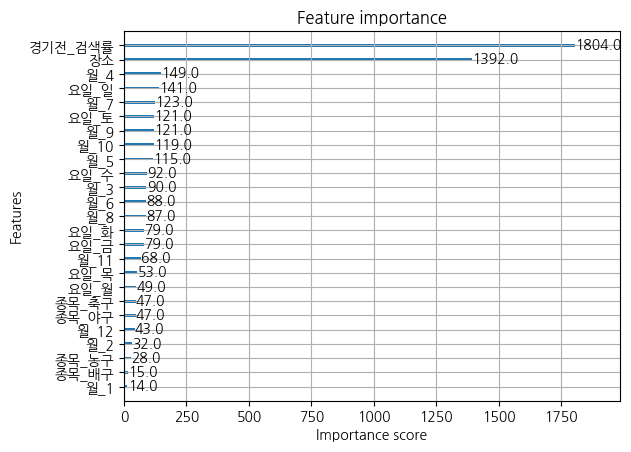

In [25]:
# xgb의 변수 중요도 시각화
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(xgb)
plt.show()

In [2]:
import pandas as pd
test_sports = pd.read_csv('test_sports.csv')

In [28]:
import pandas as pd
import pickle
from sklearn.preprocessing import OneHotEncoder

# Reload the original data and apply initial preprocessing steps
# to ensure the 'temp_sports' DataFrame has the necessary columns for encoding.
temp_sports = pd.read_csv('train_sports.csv')
temp_sports = temp_sports[['장소', '월', '종목', '요일', '경기전_검색률','관중수']]
temp_sports = temp_sports.dropna(subset=['종목'])
temp_sports[['연', '월']] = temp_sports['월'].str.extract(r'(\d{4})년\s*(\d{1,2})월').astype(int)
# At this point, '월' is the integer month, and '장소', '종목', '요일' are original strings.

# ---------------------------
# 1. 타깃 인코딩 (장소)
# ---------------------------
# Calculate target_mean on the temporary DataFrame
target_mean = temp_sports.groupby('장소')['관중수'].mean()

# Apply target encoding to the '장소' column in temp_sports
temp_sports['장소'] = temp_sports['장소'].map(target_mean)

# 타깃 인코딩 매핑 저장
with open('target_encoding.pkl', 'wb') as f:
    pickle.dump(target_mean, f)


# ---------------------------
# 2. 원핫 인코딩
# ---------------------------
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

# Fit and transform the OneHotEncoder using the original categorical columns
# '월' is now the integer month (1-12) as per previous steps.
# '종목' and '요일' are still original strings.
encoded_cols = ['월', '종목', '요일'] # These columns exist in temp_sports at this point
encoded = encoder.fit_transform(temp_sports[encoded_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(encoded_cols),
    index=temp_sports.index # Use temp_sports.index for correct alignment
)

# Replace the original categorical columns with the one-hot encoded ones
temp_sports = pd.concat([temp_sports.drop(columns=encoded_cols), encoded_df], axis=1)

# encoder 저장
with open('onehot_encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)


In [29]:
sports

,장소,경기전_검색률,관중수,연,월_1,월_2,월_3,월_4,월_5,월_6,...,종목_야구,종목_축구,요일_금,요일_목,요일_수,요일_월,요일_일,요일_토,요일_화,pred
0,2650.758065,10.931216,1203,2023,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,1502.642212
2,2650.758065,27.186975,1719,2024,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,1919.953369
3,2650.758065,61.827504,2084,2023,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,2268.149658
4,2650.758065,62.922925,2287,2023,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,2462.515137
5,2650.758065,126.617310,2547,2023,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,3013.365234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4997,2091.093023,14.644260,1554,2024,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,1763.203125
4998,2091.093023,18.216786,1678,2024,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,1857.691528
4999,2091.093023,46.478976,2626,2022,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,3017.468506
5000,2091.093023,27.818478,3048,2024,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,3034.286865


In [31]:
import pickle

# 모델 저장
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

In [32]:
test_sports.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   장소       50 non-null     object 
 1   월        50 non-null     object 
 2   종목       50 non-null     object 
 3   지역       50 non-null     object 
 4   요일       50 non-null     object 
 5   경기전_검색률  50 non-null     float64
 6   경기전_선호도  50 non-null     int64  
 7   경기후_검색률  50 non-null     int64  
 8   경기후_선호도  50 non-null     int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 3.6+ KB


In [33]:
test_sports

,장소,월,종목,지역,요일,경기전_검색률,경기전_선호도,경기후_검색률,경기후_선호도
0,서울장충체육관,2024년 11월,배구,서울특별시,수,31.370130,2827,0,0
1,인천SSG 랜더스필드,2024년 3월,야구,인천광역시,화,42.575938,322,0,0
2,화성종합실내체육관,2023년 1월,배구,경기도,일,63.298619,5858,0,0
3,서울 잠실 야구장,2023년 6월,야구,서울특별시,토,5944.770211,80901,0,0
4,잠실실내체육관,2024년 11월,농구,서울특별시,토,158.597316,2292,0,0
5,춘천송암스포츠타운,2022년 3월,축구,강원도,토,205.743870,650,0,0
6,부천종합운동장,2024년 5월,축구,경기도,토,93.600000,15920,0,0
7,서울 잠실 야구장,2022년 3월,야구,서울특별시,수,301.857144,4224,0,0
8,서울 잠실 야구장,2023년 7월,야구,서울특별시,일,5218.606068,73324,0,0
9,부산아시아드주경기장,2023년 5월,축구,부산광역시,토,196.892640,1960,0,0


# 인코딩 (test_sports)

In [35]:
import pickle

# 인코더 로드
with open('target_encoding.pkl', 'rb') as f:
  target_mean = pickle.load(f)

with open('onehot_encoder.pkl', 'rb') as f:
  encoder = pickle.load(f)

In [37]:
# 타킷 인코딩
test_sports['장소'] = test_sports['장소'].map(target_mean)
test_sports

,장소,월,종목,지역,요일,경기전_검색률,경기전_선호도,경기후_검색률,경기후_선호도
0,2696.602410,2024년 11월,배구,서울특별시,수,31.370130,2827,0,0
1,15375.032787,2024년 3월,야구,인천광역시,화,42.575938,322,0,0
2,1914.179487,2023년 1월,배구,경기도,일,63.298619,5858,0,0
3,16914.846791,2023년 6월,야구,서울특별시,토,5944.770211,80901,0,0
4,2089.379310,2024년 11월,농구,서울특별시,토,158.597316,2292,0,0
5,4220.814815,2022년 3월,축구,강원도,토,205.743870,650,0,0
6,2583.410714,2024년 5월,축구,경기도,토,93.600000,15920,0,0
7,16914.846791,2022년 3월,야구,서울특별시,수,301.857144,4224,0,0
8,16914.846791,2023년 7월,야구,서울특별시,일,5218.606068,73324,0,0
9,2663.275000,2023년 5월,축구,부산광역시,토,196.892640,1960,0,0


In [38]:
test_sports[['연', '월']] = test_sports['월'].str.extract(r'(\d{4})년\s*(\d{1,2})월').astype(int)
test_sports[['연', '월']]

,연,월
0,2024,11
1,2024,3
2,2023,1
3,2023,6
4,2024,11
5,2022,3
6,2024,5
7,2022,3
8,2023,7
9,2023,5


In [40]:
# 원핫 인코딩 적용
# 원핫 인코딩 적용
encoded = encoder.transform(test_sports[['월', '종목', '요일']])
encoded_df = pd.DataFrame(
  encoded,
  columns=encoder.get_feature_names_out(['월', '종목', '요일']),
  index=test_sports.index
)
test_sports = pd.concat([test_sports.drop(columns=['월','종목','요일']), encoded_df], axis=1)
test_sports


,장소,지역,경기전_검색률,경기전_선호도,경기후_검색률,경기후_선호도,연,월_1,월_2,월_3,...,종목_배구,종목_야구,종목_축구,요일_금,요일_목,요일_수,요일_월,요일_일,요일_토,요일_화
0,2696.602410,서울특별시,31.370130,2827,0,0,2024,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,15375.032787,인천광역시,42.575938,322,0,0,2024,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1914.179487,경기도,63.298619,5858,0,0,2023,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,16914.846791,서울특별시,5944.770211,80901,0,0,2023,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2089.379310,서울특별시,158.597316,2292,0,0,2024,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,4220.814815,강원도,205.743870,650,0,0,2022,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,2583.410714,경기도,93.600000,15920,0,0,2024,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,16914.846791,서울특별시,301.857144,4224,0,0,2022,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
8,16914.846791,서울특별시,5218.606068,73324,0,0,2023,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,2663.275000,부산광역시,196.892640,1960,0,0,2023,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [43]:
# 경기전 선호도 삭제
tetest_sports = test_sports.drop(columns=['경기전_선호도'])

In [42]:
with open('xgb_model.pkl', 'rb') as f:
  xgb = pickle.load(f)

In [54]:
# 예측
xgb.predict(test_sports)

array([ 2767.5166 , 10368.939  ,  2735.8098 , 19872.898  ,  2359.5632 ,
        7420.0215 ,  1029.7498 , 17661.65   , 21738.055  ,  2951.8186 ,
        3014.5808 ,  2291.7163 ,  2609.0195 ,  2270.6284 ,  1960.3698 ,
       11264.576  ,  5233.494  ,  2875.8267 ,  2882.6223 , 15924.432  ,
        2590.572  ,  5811.36   ,  9107.854  ,  3008.301  , 10999.514  ,
        7467.2134 ,   496.12567,  2677.2776 ,   779.96124, 12387.771  ,
       20619.889  ,  8330.91   ,  1791.6152 ,  2074.7727 , 13971.306  ,
        1882.7794 , 10915.963  , 10315.881  , 16303.594  ,  5400.2534 ,
        3421.6975 ,  4465.91   , 22418.428  ,  2604.8735 ,  3961.503  ,
       10676.562  , 20995.848  ,  6092.685  , 20336.479  ,  3592.637  ],
      dtype=float32)

In [52]:
# '지역', '연', '경기전_선호도', '경기후_검색률', '경기후_선호도' 삭제
test_sports = test_sports.drop(columns=['지역', '연', '경기전_선호도', '경기후_검색률', '경기후_선호도'], errors='ignore')

In [53]:
test = pd.read_csv('test_sports.csv')
test['관중수_예측'] = xgb.predict(test_sports)
answer = pd.read_csv('test_sports_answer.csv')
test['관중수'] = answer
test

,장소,월,종목,지역,요일,경기전_검색률,경기전_선호도,경기후_검색률,경기후_선호도,관중수_예측,관중수
0,서울장충체육관,2024년 11월,배구,서울특별시,수,31.370130,2827,0,0,2767.516602,2369
1,인천SSG 랜더스필드,2024년 3월,야구,인천광역시,화,42.575938,322,0,0,10368.939453,10541
2,화성종합실내체육관,2023년 1월,배구,경기도,일,63.298619,5858,0,0,2735.809814,3709
3,서울 잠실 야구장,2023년 6월,야구,서울특별시,토,5944.770211,80901,0,0,19872.898438,22233
4,잠실실내체육관,2024년 11월,농구,서울특별시,토,158.597316,2292,0,0,2359.563232,2218
5,춘천송암스포츠타운,2022년 3월,축구,강원도,토,205.743870,650,0,0,7420.021484,6021
6,부천종합운동장,2024년 5월,축구,경기도,토,93.600000,15920,0,0,1029.749756,1425
7,서울 잠실 야구장,2022년 3월,야구,서울특별시,수,301.857144,4224,0,0,17661.650391,18041
8,서울 잠실 야구장,2023년 7월,야구,서울특별시,일,5218.606068,73324,0,0,21738.054688,20959
9,부산아시아드주경기장,2023년 5월,축구,부산광역시,토,196.892640,1960,0,0,2951.818604,8607


# 회귀분석을 언제 쓰냐
- 상품 기획할 떄